# Optimization Using Gradient Descent in Two Variables

In this section, we extend gradient descent to functions of **two variables**.
Instead of moving along a line, we now move on a **surface**.

Gradient descent is used to find points where both partial derivatives are zero,
corresponding to **minimum points** of the function.

We will:
- Implement gradient descent for two variables
- Visualize the function using contour plots
- Observe how the algorithm behaves for different functions


## Packages

We only use standard Python libraries.


In [17]:
import numpy as np
import matplotlib.pyplot as plt

## Gradient Descent in Two Variables

For a function:

\[
f(x, y)
\]

gradient descent updates both variables simultaneously:

\[
x_{n+1} = x_n - \alpha \frac{\partial f}{\partial x}(x_n, y_n)
\]

\[
y_{n+1} = y_n - \alpha \frac{\partial f}{\partial y}(x_n, y_n)
\]

where:
- \(\alpha\) is the learning rate
- \(n\) is the iteration number


In [18]:
def gradient_descent_2d(dfdx, dfdy, x, y, learning_rate=0.1, num_iterations=100):
    for _ in range(num_iterations):
        x = x - learning_rate * dfdx(x, y)
        y = y - learning_rate * dfdy(x, y)
    return x, y

## Example 1 – Function with One Global Minimum

Consider the function:

\[
f(x, y) = (x - 1)^2 + (y - 2)^2
\]

This function has a **single global minimum** at:

\[
(x, y) = (1, 2)
\]


In [19]:
def f_example_3(x, y):
    return (x - 1)**2 + (y - 2)**2

def dfdx_example_3(x, y):
    return 2 * (x - 1)

def dfdy_example_3(x, y):
    return 2 * (y - 2)


### Visualizing the Function (Contour Plot)

Contour plots help visualize optimization in two dimensions.
Each contour represents points with the same function value.


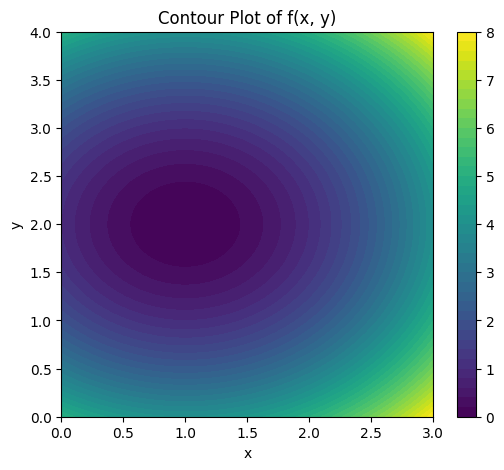

In [20]:
x_vals = np.linspace(0, 3, 200)
y_vals = np.linspace(0, 4, 200)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f_example_3(X, Y)

plt.figure(figsize=(6,5))
plt.contourf(X, Y, Z, 50)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Contour Plot of f(x, y)")
plt.show()


### Running Gradient Descent


In [21]:
num_iterations = 30
learning_rate = 0.25
x_initial = 0.5
y_initial = 0.6

x_min, y_min = gradient_descent_2d(
    dfdx_example_3,
    dfdy_example_3,
    x_initial,
    y_initial,
    learning_rate,
    num_iterations
)

print("Gradient descent result: x_min, y_min =", x_min, y_min)


Gradient descent result: x_min, y_min = 0.9999999995343387 1.9999999986961483


### Visualizing the Optimization Path


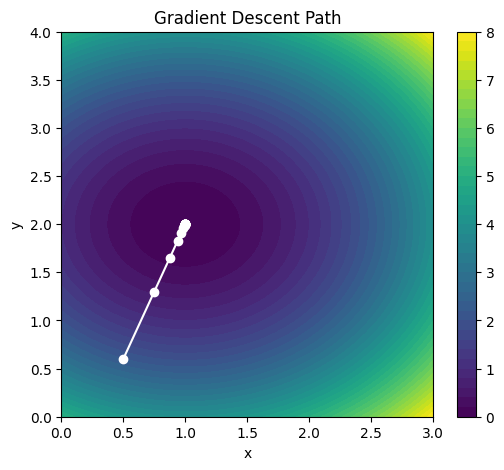

In [22]:
x, y = x_initial, y_initial
path_x, path_y = [x], [y]

for _ in range(num_iterations):
    x = x - learning_rate * dfdx_example_3(x, y)
    y = y - learning_rate * dfdy_example_3(x, y)
    path_x.append(x)
    path_y.append(y)

plt.figure(figsize=(6,5))
plt.contourf(X, Y, Z, 50)
plt.plot(path_x, path_y, 'w-o')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gradient Descent Path")
plt.colorbar()
plt.show()


## Observations

- Gradient descent successfully converges to the global minimum.
- The path follows the steepest descent direction.
- A suitable learning rate is crucial for stability.


## Example 2 – Function with Multiple Minima

Now consider a function with **multiple minima**:

\[
f(x, y) = \sin(x)\cos(y) + 0.1(x-2)^2 + 0.1(y-2)^2
\]

Gradient descent may converge to different minima depending on the starting point.


In [23]:
def f_example_4(x, y):
    return np.sin(x) * np.cos(y) + 0.1 * (x - 2)**2 + 0.1 * (y - 2)**2

def dfdx_example_4(x, y):
    return np.cos(x) * np.cos(y) + 0.2 * (x - 2)

def dfdy_example_4(x, y):
    return -np.sin(x) * np.sin(y) + 0.2 * (y - 2)


### Contour Plot of the Function

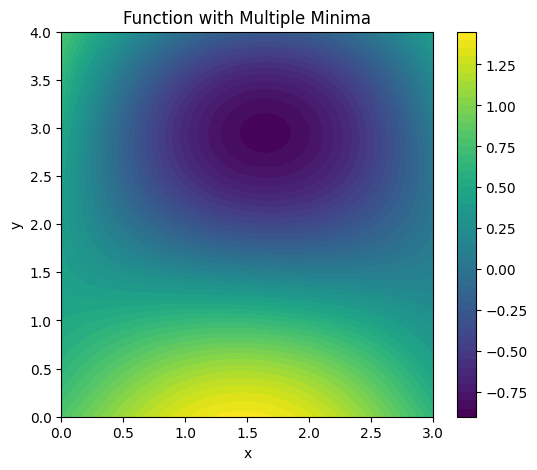

In [24]:
X, Y = np.meshgrid(x_vals, y_vals)
Z = f_example_4(X, Y)

plt.figure(figsize=(6,5))
plt.contourf(X, Y, Z, 50)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Function with Multiple Minima")
plt.show()


### Running Gradient Descent from Different Starting Points


In [25]:
learning_rate = 0.2
num_iterations = 40

# Starting point 1
x1, y1 = gradient_descent_2d(dfdx_example_4, dfdy_example_4, 0.5, 3, learning_rate, num_iterations)

# Starting point 2
x2, y2 = gradient_descent_2d(dfdx_example_4, dfdy_example_4, 2, 3, learning_rate, num_iterations)

print("Start (0.5, 3) -> Minimum at:", x1, y1)
print("Start (2, 3)   -> Minimum at:", x2, y2)


Start (0.5, 3) -> Minimum at: 1.643465227699224 2.949934115717671
Start (2, 3)   -> Minimum at: 1.6434995497105072 2.9499319932212305


## Final Conclusions

- Gradient descent generalizes naturally to multiple variables.
- Visualization helps understand optimization behavior.
- For non-convex functions, gradient descent may converge to **local minima**.
- Parameter selection is critical for successful optimization.
